Generating Metrics Radar Chart...


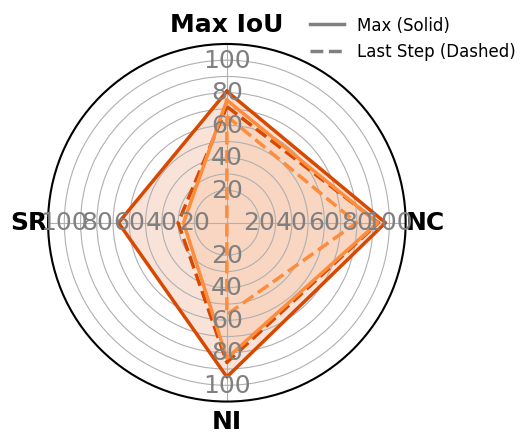

Generating Validation Progression Chart...


/tmp/ipykernel_625811/2262515255.py:264: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=True, fontsize=12, ncol=2)


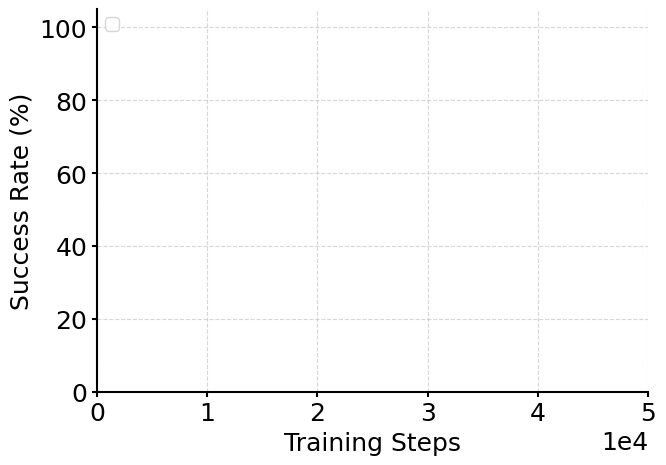

In [47]:
import os
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# --- 1. Publication-Ready Style Settings ---
plt.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 16,
    'font.family': 'sans-serif',
    'lines.linewidth': 2.5,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
})

COLORS = {
    # --- Diffusion Theme: Sequential Blues (Light to Dark) ---
    'Diffusion-25': '#9ecae1',   # Light Blue
    'Diffusion-50': '#6baed6',   # Medium-Light Blue
    'Diffusion-100': '#3182bd',  # Medium-Dark Blue
    'Diffusion-200': '#08519c',  # Deep Blue

    # --- LaGarNet Theme: Warm Oranges (Contrasting) ---
    "Task-Specific LaGarNet": '#fd8d3c',  # Bright Orange
    "All-Garment LaGarNet": '#d94801'     # Dark Rust/Burnt Orange
}

# --- 2. Helper Functions ---
def parse_list(val):
    """Safely converts string lists to Python lists, wraps single numbers, and clips between 0 and 1."""
    parsed_list = []
    
    # 1. Handle missing/NaN values
    if pd.isna(val):
        return []
    
    # 2. If it's already a list, grab it
    if isinstance(val, list):
        parsed_list = val
        
    # 3. If it's a string, try to evaluate it
    elif isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                parsed_list = parsed
            else:
                parsed_list = [parsed] # Wrap single evaluated numbers in a list
        except (ValueError, SyntaxError):
            # Fallback: if it's a string like "0.85" that isn't a list
            try:
                parsed_list = [float(val)]
            except ValueError:
                parsed_list = []
                
    # 4. If it's a raw integer or float (like 0 or 0.95)
    elif isinstance(val, (int, float)):
        parsed_list = [val]
        
    # 5. Clip all successfully parsed values between 0.0 and 1.0
    # Using max(0.0, min(1.0, x)) is a fast, standard way to clamp values in pure Python
    clipped_list = []
    for x in parsed_list:
        try:
            clipped_list.append(max(0.0, min(1.0, float(x))))
        except (ValueError, TypeError):
            # Just in case some un-castable junk made it into the list
            pass 
            
    return clipped_list

def aggregate_performance_custom(csv_path, iou_thresh=0.8, nc_thresh=0.9, max_steps=20):
    """Calculates SR (custom criteria), Max IoU, Max NC, and Max NI up to max_steps."""
    df = pd.read_csv(csv_path)
    
    # Parse columns (this will now work!)
    df["iou_flat"] = df["evaluation/max_IoU_to_flattened"].apply(parse_list)
    df["nc"] = df["evaluation/normalised_coverage"].apply(parse_list)
    df["ni"] = df["evaluation/normalised_improvement"].apply(parse_list)
    
    # 1. Success Rate (SR) within max_steps
    new_first_success_flags = []
    for iou_list, nc_list in zip(df["iou_flat"], df["nc"]):
        # Slice the lists up to max_steps (if provided)
        iou_sliced = iou_list[:max_steps] if max_steps is not None else iou_list
        nc_sliced = nc_list[:max_steps] if max_steps is not None else nc_list
        
        if any((i > iou_thresh and n > nc_thresh) for i, n in zip(iou_sliced, nc_sliced)):
            new_first_success_flags.append(1)
        else:
            new_first_success_flags.append(0)

    # 2. Quality Metrics (Max per episode within max_steps)
    def safe_max(lst):
        """Slices the list and safely returns the max, handling empty lists."""
        sliced = lst[:max_steps] if max_steps is not None else lst
        return np.max(sliced) if len(sliced) > 0 else 0.0

    def safe_final(lst):
        """Value at the last executed step within the horizon (stability metric)."""
        sliced = lst[:max_steps] if max_steps is not None else lst
        return sliced[-1] if len(sliced) > 0 else 0.0

    max_iou = [safe_max(x) for x in df["iou_flat"]]
    max_nc = [safe_max(x) for x in df["nc"]]
    max_ni = [safe_max(x) for x in df["ni"]]

    # --- Last-executed-step (stability) metrics, mirroring magpie/alignment_sim.ipynb ---
    final_iou = [safe_final(x) for x in df["iou_flat"]]
    final_nc = [safe_final(x) for x in df["nc"]]
    final_ni = [safe_final(x) for x in df["ni"]]
    final_success_flags = [
        1 if (fi > iou_thresh and fn > nc_thresh) else 0
        for fi, fn in zip(final_iou, final_nc)
    ]

    return {
        "SR_mean": np.mean(new_first_success_flags),
        "SR_std": np.std(new_first_success_flags),
        "Max IoU_mean": np.mean(max_iou), "Max IoU_std": np.std(max_iou),
        "Max NC_mean": np.mean(max_nc),   "Max NC_std": np.std(max_nc),
        "Max NI_mean": np.mean(max_ni),   "Max NI_std": np.std(max_ni),
        # Last-executed-step (final) values within the horizon
        "Final SR_mean": np.mean(final_success_flags),
        "Final SR_std": np.std(final_success_flags),
        "Final IoU_mean": np.mean(final_iou), "Final IoU_std": np.std(final_iou),
        "Final NC_mean": np.mean(final_nc),   "Final NC_std": np.std(final_nc),
        "Final NI_mean": np.mean(final_ni),   "Final NI_std": np.std(final_ni),
    }

# --- 3. Plotting Functions ---

def plot_radar_metrics(results_df):
    """
    Radar (Spider) Chart plotting the mean values of Max IoU, NC, NI, and SR.
    Scaled to 0-100.
    """
    metrics = ["Max IoU", "Max NC", "Max NI", "SR"]
    final_metrics = ["Final IoU", "Final NC", "Final NI", "Final SR"]
    display_labels = ["Max IoU", "NC", "NI", "SR"] 
    experiments = results_df["experiment"].unique()
    
    N = len(metrics)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1] 
    
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    plt.xticks(angles[:-1], display_labels, fontweight='bold')
    
    tick_vals = [20, 30, 40, 50, 60, 70, 80, 90, 100]
    tick_labels = ["20", "", "40", "", "60", "", "80", "", "100"]
    plt.yticks(tick_vals, [], color="grey")
    plt.ylim(0, 110)
    
    for angle in angles[:-1]:
        for val, label in zip(tick_vals, tick_labels):
            if label != "":
                ax.text(angle, val, label, color="grey", ha='center', va='center')
    
    for exp in experiments:
        row = results_df[results_df["experiment"] == exp].iloc[0]
        
        values = [row[f"{m}_mean"] * 100 for m in metrics]
        values += values[:1]
        
        color = COLORS.get(exp, 'gray')
        
        ax.plot(angles, values, linewidth=2.5, linestyle='solid', label=exp, color=color)
        ax.fill(angles, values, color=color, alpha=0.15)

        # Dashed = last-executed-step value (stability)
        final_values = [row[f"{fm}_mean"] * 100 for fm in final_metrics]
        final_values += final_values[:1]
        ax.plot(angles, final_values, linewidth=2.5, linestyle='dashed', color=color)

    # Line-style legend (Max = solid, Last = dashed)
    style_lines = [Line2D([0], [0], color='grey', lw=2.5, linestyle='solid'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle='dashed')]
    ax.legend(style_lines, ['Max (Solid)', 'Last Step (Dashed)'],
              loc='upper right', bbox_to_anchor=(1.35, 1.12), fontsize=12, frameon=False)

    plt.tight_layout()
    plt.savefig('metrics_radar.png', dpi=300)
    plt.show()

def plot_validation_progression(diffusion_csv, lagarnet_csv, smooth_span=15):
    """
    Combines data from Diffusion and LaGarNet CSVs into one plot with smoothed lines.
    Scaled to 0-100%.
    """
    fig, ax = plt.subplots(figsize=(7, 5))

    # Helper function to avoid writing the same plotting code twice
    def plot_lines(df, prefix, label):
        col_mean = f"{prefix} - val/success_rate"
        col_min = f"{prefix} - val/success_rate__MIN"
        col_max = f"{prefix} - val/success_rate__MAX"
        
        if col_mean in df.columns:
            color = COLORS.get(label, 'gray')
            
            # Scale by 100
            scaled_mean = df[col_mean] * 100
            smoothed_mean = scaled_mean.ewm(span=smooth_span, adjust=False).mean()
            
            ax.plot(df['Step'], scaled_mean, color=color, alpha=0.15, linewidth=1)
            ax.plot(df['Step'], smoothed_mean, label=label, color=color, linewidth=2.5)
            
            if col_min in df.columns and col_max in df.columns:
                smoothed_min = (df[col_min] * 100).ewm(span=smooth_span, adjust=False).mean()
                smoothed_max = (df[col_max] * 100).ewm(span=smooth_span, adjust=False).mean()
                ax.fill_between(df['Step'], smoothed_min, smoothed_max, color=color, alpha=0.15)

    # --- 1. Plot Diffusion Data ---
    if os.path.exists(diffusion_csv):
        df_diff = pd.read_csv(diffusion_csv)
        df_diff = df_diff[(df_diff['Step'] >= 0) & (df_diff['Step'] <= 50000)]
        
        diff_map = [
            ("diffusion_single_picker_single_primitive_multi_longsleeve_flattening_demo_200", "Diffusion-200"),
            ("diffusion_single_picker_single_primitive_multi_longsleeve_flattening_demo_100", "Diffusion-100"),
            ("diffusion_single_picker_single_primitive_multi_longsleeve_flattening_demo_50",  "Diffusion-50"),
            ("diffusion_single_picker_single_primitive_multi_longsleeve_flattening_demo_25",  "Diffusion-25"),
        ]
        
        for prefix, label in diff_map:
            plot_lines(df_diff, prefix, label)
    else:
        print(f"Warning: Diffusion CSV not found: {diffusion_csv}")

    # --- 2. Plot LaGarNet Data ---
    if os.path.exists(lagarnet_csv):
        df_lag = pd.read_csv(lagarnet_csv)
        df_lag = df_lag[(df_lag['Step'] >= 0) & (df_lag['Step'] <= 50000)]
        
        lag_map = [
            ("lagarnet_single_picker_single_primitive_multi_longsleeve_flattening_sanity_check", "All-Garment\n LaGarNet"),
            ("lagarnet_single_picker_single_primitive_multi_longsleeve_flattening_longsleeve_only", "Task-Specific\n LaGarNet")
        ]
        
        for prefix, label in lag_map:
            plot_lines(df_lag, prefix, label)
    else:
        print(f"Warning: LaGarNet CSV not found: {lagarnet_csv}")

    # --- 3. Formatting ---
    ax.set_xlabel('Training Steps')
    ax.set_ylabel('Success Rate (%)') # Updated Label
    
    # Depending on how many models you have, you might need to drop ncol down to 2 
    # so the legend doesn't overlap with the lines.
    ax.legend(loc='upper left', frameon=True, fontsize=12, ncol=2) 
    
    ax.set_ylim(0, 105) # Updated Y-limit for 0-100 scale
    ax.set_xlim(0, 50000)
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('validation_progression.png', dpi=300)
    plt.show()

# --- 4. Main Execution ---

# PATHS (Update these to your file locations)
data_dir = "/media/halid/T7/garment_folding_data/lagarnet_data"
diffusion_csv = "diffusion_val_success_rate.csv"
lagarnet_csv = "lagarnet_val_success_rate.csv"

# Experiments List 
experiments = [
    {"name": "diffusion_single_picker_single_primitive_multi_longsleeve_flattening_demo_25", "label": "Diffusion-25", "check": "eval_checkpoint_-2"},
    {"name": "diffusion_single_picker_single_primitive_multi_longsleeve_flattening_demo_50", "label": "Diffusion-50", "check": "eval_checkpoint_-2"},
    {"name": "diffusion_single_picker_single_primitive_multi_longsleeve_flattening_demo_100", "label": "Diffusion-100", "check": "eval_checkpoint_-2"},
    {"name": "diffusion_single_picker_single_primitive_multi_longsleeve_flattening_demo_200", "label": "Diffusion-200", "check": "eval_checkpoint_-2"},
    {"name": "comp_org_lagarnet_single_picker_single_primitive_multi_longsleeve_flattening_retrain_with_diffusion_200", "label": "All-Garment LaGarNet", "check": "eval_checkpoint_-2"},
    {"name": "lagarnet_single_picker_single_primitive_multi_longsleeve_flattening_longsleeve_only", "label": "Task-Specific LaGarNet", "check": "eval_checkpoint_-2"},
]

# A. Generate Radar Chart Data
rows = []
for exp in experiments:
    path = os.path.join(data_dir, exp["name"], exp["check"], "performance.csv")
    if os.path.exists(path):
        m = aggregate_performance_custom(path, iou_thresh=0.8, nc_thresh=0.9)
        m["experiment"] = exp["label"]
        rows.append(m)
    else:
        pass

results_df = pd.DataFrame(rows)

# B. Plot Both Charts
if not results_df.empty:
    print("Generating Metrics Radar Chart...")
    plot_radar_metrics(results_df)

print("Generating Validation Progression Chart...")
plot_validation_progression(diffusion_csv, lagarnet_csv, smooth_span=15)

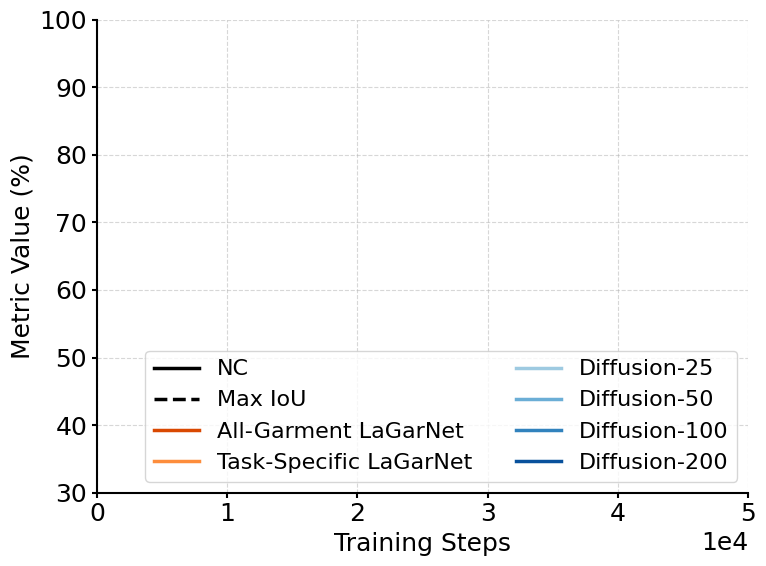

In [48]:
diffusion_iou_csv = "diffusion_val_max_IoU.csv"
diffusion_nc_csv = "diffusion_val_normalised_coverage.csv"
lagarnet_iou_csv = "lagarnet_val_max_IoU.csv"
lagarnet_nc_csv = "lagarnet_val_normalised_coverage.csv"


def plot_nc_vs_iou_progression(diffusion_iou_csv, diffusion_nc_csv, lagarnet_iou_csv, lagarnet_nc_csv, smooth_span=15):
    """
    Combines data from Diffusion and LaGarNet CSVs into one plot.
    Compares NC (Solid Line) vs Max IoU (Dashed Line) progressions.
    Values are scaled by 100 to represent percentages (0-100).
    smooth_span controls the amount of smoothing (higher = smoother).
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    diff_map = [
        ("diffusion_single_picker_single_primitive_multi_longsleeve_flattening_demo_25",  "Diffusion-25"),
        ("diffusion_single_picker_single_primitive_multi_longsleeve_flattening_demo_50",  "Diffusion-50"),
        ("diffusion_single_picker_single_primitive_multi_longsleeve_flattening_demo_100", "Diffusion-100"),
        ("diffusion_single_picker_single_primitive_multi_longsleeve_flattening_demo_200", "Diffusion-200"),
    ]
    
    # --- UPDATED: Group LaGarNet experiments into a map ---
    lag_map = [
        ("lagarnet_single_picker_single_primitive_multi_longsleeve_flattening_sanity_check", "All-Garment LaGarNet"),
        ("lagarnet_single_picker_single_primitive_multi_longsleeve_flattening_longsleeve_only", "Task-Specific LaGarNet")
    ]

    # --- Helper to plot an experiment's metrics ---
    def plot_experiment(df_iou, df_nc, prefix, label):
        iou_col = f"{prefix} - val/reward/max_IoU_last_mean"
        nc_col = f"{prefix} - val/reward/normalised_coverage_last_mean"
        
        color = COLORS.get(label, 'gray')

        # 1. Plot Normalised Coverage (NC) as SOLID lines
        if df_nc is not None and nc_col in df_nc.columns:
            # Scale raw data by 100
            scaled_nc = df_nc[nc_col] * 100
            smoothed_nc = scaled_nc.ewm(span=smooth_span, adjust=False).mean()
            
            # Faint raw data background
            ax.plot(df_nc['Step'], scaled_nc, color=color, alpha=0.15, linestyle='-', linewidth=1)
            # Solid Smoothed line
            ax.plot(df_nc['Step'], smoothed_nc, color=color, linestyle='-', linewidth=2.5)

        # 2. Plot Max IoU as DASHED lines
        if df_iou is not None and iou_col in df_iou.columns:
            # Scale raw data by 100
            scaled_iou = df_iou[iou_col] * 100
            smoothed_iou = scaled_iou.ewm(span=smooth_span, adjust=False).mean()
            
            # Faint raw data background
            ax.plot(df_iou['Step'], scaled_iou, color=color, alpha=0.15, linestyle='--', linewidth=1)
            # Dashed Smoothed line
            ax.plot(df_iou['Step'], smoothed_iou, color=color, linestyle='--', linewidth=2.5)

    # --- Load Data safely ---
    def load_and_filter(path):
        if os.path.exists(path):
            df = pd.read_csv(path)
            return df[(df['Step'] >= 0) & (df['Step'] <= 50000)]
        return None

    df_diff_iou = load_and_filter(diffusion_iou_csv)
    df_diff_nc = load_and_filter(diffusion_nc_csv)
    df_lag_iou = load_and_filter(lagarnet_iou_csv)
    df_lag_nc = load_and_filter(lagarnet_nc_csv)

    # --- Plot Diffusion Data ---
    for prefix, label in diff_map:
        plot_experiment(df_diff_iou, df_diff_nc, prefix, label)

    # --- Plot LaGarNet Data ---
    # UPDATED: Loop through the lag_map
    for prefix, label in lag_map:
        plot_experiment(df_lag_iou, df_lag_nc, prefix, label)

    # --- Custom Legend Configuration ---
    custom_lines = []
    custom_labels = []

    # 1. Line Styles (Metrics)
    custom_lines.append(Line2D([0], [0], color='black', lw=2.5, linestyle='-'))
    custom_labels.append('NC')
    
    custom_lines.append(Line2D([0], [0], color='black', lw=2.5, linestyle='--'))
    custom_labels.append('Max IoU')

    # Add a blank spacer to align a 2-column legend nicely
    # custom_lines.append(Line2D([0], [0], color='none')) 
    # custom_labels.append('')
    # custom_lines.append(Line2D([0], [0], color='none')) 
    # custom_labels.append('')

    # 2. Colors (Experiments)
    # UPDATED: dynamically grab all labels from both diff_map and lag_map
    all_labels = [l for _, l in lag_map] + [l for _, l in diff_map]
    for label in all_labels:
        if label == ' ':
            custom_lines.append(Line2D([0], [0], color='none')) 
            custom_labels.append('')
        else:
            custom_lines.append(Line2D([0], [0], color=COLORS.get(label, 'gray'), lw=2.5, linestyle='-'))
            custom_labels.append(label)

    # --- Formatting ---
    ax.set_xlabel('Training Steps')
    ax.set_ylabel('Metric Value (%)') # Updated to show percentage
    
    # You might need to change ncol=3 to ncol=2 if the legend box gets too wide with 6 models
    ax.legend(custom_lines, custom_labels, loc='lower right', frameon=True, ncol=2)
    
    ax.set_ylim(30, 100) 
    ax.set_xlim(0, 50000)
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Cleaned up duplicate layout calls
    plt.tight_layout()
    plt.savefig('progression_nc_vs_iou.png', dpi=300)
    plt.show()

# Execution
plot_nc_vs_iou_progression(
    diffusion_iou_csv=diffusion_iou_csv, 
    diffusion_nc_csv=diffusion_nc_csv, 
    lagarnet_iou_csv=lagarnet_iou_csv, 
    lagarnet_nc_csv=lagarnet_nc_csv, 
    smooth_span=15
)

In [49]:
import os
import pandas as pd
import numpy as np

# --- 5. Transfer Evaluation Aggregation ---

data_dir = '/media/halid/T7/garment_folding_data'

transfer_eval_exp = [
    # {'label': 'LaGarNet-Sanity', 'exp_dir': 'transfer_eval_lagarnet_sanity'},
    
    {'label': 'GC-Diffusion', 'exp_dir': 'transfer_eval_comp_org_gc_diffusion'},
    {'label': 'GC-Diffusion-Comp', 'exp_dir': 'transfer_eval_comp_gc_diffusion'},
    {'label': 'GC-RSSM-Diffusion', 'exp_dir': 'transfer_eval_gc_rssm_diffusion'},
    {'label': 'LaGarNet-CNN-Diffusion', 'exp_dir': 'transfer_eval_lagarnet_cnn_diffusion'},
    {'label': 'LaGarNet-Comp', 'exp_dir': 'transfer_eval_comp_lagarnet'},
    {'label': 'LaGarNet-RSSM', 'exp_dir': 'transfer_eval_comp_rssm'},
    {'label': 'LaGarNet', 'exp_dir': 'transfer_eval_final_lagarnet_reward_v2_alpha_0_3'},
]

arenas = [
    {'label': 'Longsleeve', 'exp_dir': 'multi_longsleeve_single_picker_readjust_pick_provide_semkey_pixel_no_success_stop_resol_128_train_200'},
    {'label': 'Trousers', 'exp_dir': 'multi_trousers_single_picker_readjust_pick_provide_semkey_pixel_no_success_stop_resol_128_train_200'},
    {'label': 'Skirt', 'exp_dir': 'multi_skirt_single_picker_readjust_pick_provide_semkey_pixel_no_success_stop_resol_128_train_200'},
    {'label': 'Dress', 'exp_dir': 'multi_dress_single_picker_readjust_pick_provide_semkey_pixel_no_success_stop_resol_128_train_200'}
]

aggregated_results = []

print("Aggregating transfer evaluation metrics across arenas...\n")

for exp in transfer_eval_exp:
    exp_metrics = {
        'SR': [],
        'Max_IoU': [],
        'Max_NC': [],
        'Max_NI': [],
        'Final_SR': [],
        'Final_IoU': [],
        'Final_NC': [],
        'Final_NI': []
    }
    
    total_trajectories = 0  # Initialize a counter for the total trajectories
    
    for arena in arenas:
        csv_path = os.path.join(data_dir, exp['exp_dir'], arena['exp_dir'], 'eval_checkpoint_-2', 'performance.csv')
        
        if os.path.exists(csv_path):
            # Read the CSV just to get the number of rows (trajectories)
            arena_df = pd.read_csv(csv_path)
            total_trajectories += len(arena_df)
            
            # Parse the CSV using your helper function
            metrics = aggregate_performance_custom(csv_path, iou_thresh=0.8, nc_thresh=0.9)
            
            exp_metrics['SR'].append(metrics['SR_mean'])
            exp_metrics['Max_IoU'].append(metrics['Max IoU_mean'])
            exp_metrics['Max_NC'].append(metrics['Max NC_mean'])
            exp_metrics['Max_NI'].append(metrics['Max NI_mean'])
            exp_metrics['Final_SR'].append(metrics['Final SR_mean'])
            exp_metrics['Final_IoU'].append(metrics['Final IoU_mean'])
            exp_metrics['Final_NC'].append(metrics['Final NC_mean'])
            exp_metrics['Final_NI'].append(metrics['Final NI_mean'])
            
    # Calculate the overall mean and std across all found arenas, multiplying by 100
    if exp_metrics['SR']: 
        aggregated_results.append({
            'Experiment': exp['label'],
            'Trajectories': total_trajectories,  # Added the total count here
            
            'Overall SR': np.mean(exp_metrics['SR']) * 100,
            
            'Overall Max IoU': np.mean(exp_metrics['Max_IoU']) * 100,
            'Max IoU Std': np.std(exp_metrics['Max_IoU']) * 100,
            
            'Overall Max NC': np.mean(exp_metrics['Max_NC']) * 100,
            'Max NC Std': np.std(exp_metrics['Max_NC']) * 100,
            
            'Overall Max NI': np.mean(exp_metrics['Max_NI']) * 100,
            'Max NI Std': np.std(exp_metrics['Max_NI']) * 100,

            'Overall Final SR': np.mean(exp_metrics['Final_SR']) * 100,

            'Overall Final IoU': np.mean(exp_metrics['Final_IoU']) * 100,
            'Final IoU Std': np.std(exp_metrics['Final_IoU']) * 100,

            'Overall Final NC': np.mean(exp_metrics['Final_NC']) * 100,
            'Final NC Std': np.std(exp_metrics['Final_NC']) * 100,

            'Overall Final NI': np.mean(exp_metrics['Final_NI']) * 100,
            'Final NI Std': np.std(exp_metrics['Final_NI']) * 100
        })

# Convert to a DataFrame
df_transfer_eval = pd.DataFrame(aggregated_results)

if not df_transfer_eval.empty:
    # Optional: Round the numbers for a cleaner display in the console
    df_display = df_transfer_eval.round(2)
    print("--- Transfer Evaluation Results (Scaled by 100, Averaged Across Arenas) ---")
    print(df_display.to_string(index=False))
else:
    print("No data found for the transfer evaluations. Please check your data_dir and experiment paths.")

def generate_latex_table(df):
    """Formats the dataframe into a LaTeX table string for papers."""
    df_table = pd.DataFrame()
    df_table['Method'] = df['Experiment']
    
    # Format SR (No % symbol)
    df_table['SR'] = df['Overall SR'].apply(lambda x: f"{x:.1f}")
    
    # Format metrics with Mean \pm Std wrapped in LaTeX math mode ($...$)
    df_table['Max IoU'] = df.apply(lambda row: f"{row['Overall Max IoU']:.1f} $\pm$ {row['Max IoU Std']:.1f}", axis=1)
    df_table['Max NC'] = df.apply(lambda row: f"{row['Overall Max NC']:.1f} $\pm$ {row['Max NC Std']:.1f}", axis=1)
    df_table['Max NI'] = df.apply(lambda row: f"{row['Overall Max NI']:.1f} $\pm$ {row['Max NI Std']:.1f}", axis=1)

    # Final-step (stability) columns
    df_table['Final SR'] = df['Overall Final SR'].apply(lambda x: f"{x:.1f}")
    df_table['Final IoU'] = df.apply(lambda row: f"{row['Overall Final IoU']:.1f} $\pm$ {row['Final IoU Std']:.1f}", axis=1)
    df_table['Final NC'] = df.apply(lambda row: f"{row['Overall Final NC']:.1f} $\pm$ {row['Final NC Std']:.1f}", axis=1)
    df_table['Final NI'] = df.apply(lambda row: f"{row['Overall Final NI']:.1f} $\pm$ {row['Final NI Std']:.1f}", axis=1)
    
    print("\n--- LaTeX Table Output ---")
    # escape=False ensures the $ and \pm render correctly in LaTeX
    latex_string = df_table.to_latex(index=False, escape=False, column_format='lcccccccc')
    print(latex_string)

# Call the function with your aggregated dataframe
if not df_transfer_eval.empty:
    generate_latex_table(df_transfer_eval)

Aggregating transfer evaluation metrics across arenas...

No data found for the transfer evaluations. Please check your data_dir and experiment paths.


In [50]:
import os
import pandas as pd
import numpy as np

data_dir = '/media/halid/T7/garment_folding_data'

# 1. Define all the methods to match the exact columns of your target table
transfer_eval_exp = [
    {'label': 'ClothFunnels', 'exp_dir': 'transfer_eval_cloth_funnels_place_only'},  
    {'label': 'MEDOR', 'exp_dir': 'transfer_eval_medor'}, # Has None, needs to be handled
    {'label': 'Task-Specific  Diffusion Policy', 'exp_dir': 'transfer_eval_diffusion_200'},
    {'label': 'Task-Specific PlaNet-ClothPick', 'exp_dir': 'transfer_eval_task_specific_planet_clothpick'},
    {'label': 'All-Garment PlaNet-ClothPick', 'exp_dir': 'transfer_eval_all_garment_planet_clothpick'},
    {'label': 'Task-Specific LaGarNet', 'exp_dir': 'transfer_eval_task_specific_lagarnet'},
    {'label': 'All-Garment LaGarNet', 'exp_dir': 'transfer_eval_final_lagarnet_reward_v2_alpha_0_3'},
    {'label': 'Human', 'exp_dir': 'transfer_eval_human'},
]

arenas = [
    {'exp_dir': 'multi_longsleeve_single_picker_readjust_pick_provide_semkey_pixel_no_success_stop_resol_128_train_200_horizon_30'}
]

step_limits = [5, 10, 20, 30]

# Dictionary to store the formatted string for each cell: results[step][method][metric]
formatted_results = {step: {exp['label']: {} for exp in transfer_eval_exp} for step in step_limits}

for exp in transfer_eval_exp:
    label = exp['label']
    
    for step in step_limits:
        
        # --- FIX: Safely skip if exp_dir is None ---
        if exp['exp_dir'] is None:
            formatted_results[step][label] = {'SR': '-', 'NI': '-', 'NC': '-', 'Max IoU': '-', 'Final SR': '-', 'Final NI': '-', 'Final NC': '-', 'Final IoU': '-'}
            continue 
            
        # --- AUTOMATIC CSV PARSING ---
        temp_metrics = {'SR_successes': 0, 'Total_traj': 0, 'NI_mean': [], 'NI_std': [], 'NC_mean': [], 'NC_std': [], 'IoU_mean': [], 'IoU_std': [],
                        'Final_SR_successes': 0, 'Final_NI_mean': [], 'Final_NI_std': [], 'Final_NC_mean': [], 'Final_NC_std': [], 'Final_IoU_mean': [], 'Final_IoU_std': []}
        
        for arena in arenas:
            csv_path = os.path.join(data_dir, exp['exp_dir'], arena['exp_dir'], 'eval_checkpoint_-2', 'performance.csv')
            
            if os.path.exists(csv_path):
                arena_df = pd.read_csv(csv_path)
                total_trajectories = len(arena_df)
                
                # Call your newly modified custom function here
                metrics = aggregate_performance_custom(csv_path, max_steps=step)
                
                temp_metrics['Total_traj'] += total_trajectories
                temp_metrics['SR_successes'] += int(metrics['SR_mean'] * total_trajectories)
                
                temp_metrics['NI_mean'].append(metrics['Max NI_mean'] * 100)
                temp_metrics['NI_std'].append(metrics['Max NI_std'] * 100)
                temp_metrics['NC_mean'].append(metrics['Max NC_mean'] * 100)
                temp_metrics['NC_std'].append(metrics['Max NC_std'] * 100)
                temp_metrics['IoU_mean'].append(metrics['Max IoU_mean'] * 100)
                temp_metrics['IoU_std'].append(metrics['Max IoU_std'] * 100)

                temp_metrics['Final_SR_successes'] += int(metrics['Final SR_mean'] * total_trajectories)
                temp_metrics['Final_NI_mean'].append(metrics['Final NI_mean'] * 100)
                temp_metrics['Final_NI_std'].append(metrics['Final NI_std'] * 100)
                temp_metrics['Final_NC_mean'].append(metrics['Final NC_mean'] * 100)
                temp_metrics['Final_NC_std'].append(metrics['Final NC_std'] * 100)
                temp_metrics['Final_IoU_mean'].append(metrics['Final IoU_mean'] * 100)
                temp_metrics['Final_IoU_std'].append(metrics['Final IoU_std'] * 100)
                
        # Format the strings for LaTeX
        if temp_metrics['Total_traj'] > 0:
            formatted_results[step][label]['SR'] = f"{temp_metrics['SR_successes']}/{temp_metrics['Total_traj']}"
            formatted_results[step][label]['NI'] = f"{np.mean(temp_metrics['NI_mean']):.1f} $\pm$ {np.mean(temp_metrics['NI_std']):.1f}"
            formatted_results[step][label]['NC'] = f"{np.mean(temp_metrics['NC_mean']):.1f} $\pm$ {np.mean(temp_metrics['NC_std']):.1f}"
            formatted_results[step][label]['Max IoU'] = f"{np.mean(temp_metrics['IoU_mean']):.1f} $\pm$ {np.mean(temp_metrics['IoU_std']):.1f}"
            formatted_results[step][label]['Final SR'] = f"{temp_metrics['Final_SR_successes']}/{temp_metrics['Total_traj']}"
            formatted_results[step][label]['Final NI'] = f"{np.mean(temp_metrics['Final_NI_mean']):.1f} $\pm$ {np.mean(temp_metrics['Final_NI_std']):.1f}"
            formatted_results[step][label]['Final NC'] = f"{np.mean(temp_metrics['Final_NC_mean']):.1f} $\pm$ {np.mean(temp_metrics['Final_NC_std']):.1f}"
            formatted_results[step][label]['Final IoU'] = f"{np.mean(temp_metrics['Final_IoU_mean']):.1f} $\pm$ {np.mean(temp_metrics['Final_IoU_std']):.1f}"
        else:
            # Handle missing data
            formatted_results[step][label] = {'SR': '-', 'NI': '-', 'NC': '-', 'Max IoU': '-', 'Final SR': '-', 'Final NI': '-', 'Final NC': '-', 'Final IoU': '-'}


# --- AUTOMATIC HIGHLIGHTING FOR TOP 3 VALUES (WITH TIES) ---
def get_numeric_value(val_str, metric):
    """Helper to extract the numeric value from the LaTeX formatted string."""
    if val_str == '-':
        return -1.0
    
    try:
        if metric in ('SR', 'Final SR'):
            # e.g., '14/30' -> extract 14
            return float(val_str.split('/')[0])
        else:
            # e.g., '42.7 $\pm$ 19.5' -> extract 42.7
            return float(val_str.split(' $\pm$')[0].strip())
    except:
        return -1.0

metrics_list = ['NI', 'NC', 'Max IoU', 'SR', 'Final NI', 'Final NC', 'Final IoU', 'Final SR']

for step in step_limits:
    for metric in metrics_list:
        
        # Store a list of (numeric_value, method_label)
        val_label_pairs = []
        
        for exp in transfer_eval_exp:
            label = exp['label']
            
            # Skip missing data and the 'Human' baseline
            if label not in formatted_results[step]:
                continue
                
            val_str = formatted_results[step][label].get(metric, '-')
            num_val = get_numeric_value(val_str, metric)
            
            if num_val >= 0:
                val_label_pairs.append((num_val, label))
                
        # Skip if no data was found
        if not val_label_pairs:
            continue
            
        # Get UNIQUE scores and sort them highest to lowest to establish the ranks
        unique_scores = sorted(list(set([val for val, _ in val_label_pairs])), reverse=True)
        
        # Apply the highlights based on matching the score to the rank thresholds
        for val, method in val_label_pairs:
            original_str = formatted_results[step][method][metric]
            
            if len(unique_scores) > 0 and val == unique_scores[0]:
                formatted_results[step][method][metric] = "\\cellcolor{green!25}" + original_str
            elif len(unique_scores) > 1 and val == unique_scores[1]:
                formatted_results[step][method][metric] = "\\cellcolor{yellow!25}" + original_str
            elif len(unique_scores) > 2 and val == unique_scores[2]:
                formatted_results[step][method][metric] = "\\cellcolor{red!25}" + original_str


def generate_custom_latex_table(results, methods, steps):
    """Generates the exact LaTeX table structure required."""
    columns = [m['label'] for m in methods]
    
    # 1. Header with custom alignments
    latex = "\\begin{tabular}{l|cp{1.9cm}p{1.9cm}p{2.1cm}p{2.1cm}p{1.8cm}p{1.8cm}||c}\n"
    latex += "Longsleeve & " + " & ".join(columns) + " \\\\\n"
    
    # 2. Body grouped by steps
    for i, step in enumerate(steps):
        latex += "\\hline\n"
        
        # Row 1: NI
        ni_row = [f"NI $\\uparrow$ ({step} steps)"]
        for col in columns:
            ni_row.append(results[step][col].get('NI', '-'))
        latex += " & ".join(ni_row) + " \\\\\n"
        
        # Row 2: NC
        nc_row = ["NC $\\uparrow$"]
        for col in columns:
            nc_row.append(results[step][col].get('NC', '-'))
        latex += " & ".join(nc_row) + " \\\\\n"
        
        # Row 3: Max IoU
        iou_row = ["Max IoU $\\uparrow$"]
        for col in columns:
            iou_row.append(results[step][col].get('Max IoU', '-'))
        latex += " & ".join(iou_row) + " \\\\\n"
        
        # Row 4: SR
        sr_row = ["SR $\\uparrow$"]
        for col in columns:
            sr_row.append(results[step][col].get('SR', '-'))
        latex += " & ".join(sr_row) + " \\\\\n"

        # Final-step (stability) rows
        for metric, head in [('Final NI', 'Final NI $\\uparrow$'),
                             ('Final NC', 'Final NC $\\uparrow$'),
                             ('Final IoU', 'Final IoU $\\uparrow$'),
                             ('Final SR', 'Final SR $\\uparrow$')]:
            row = [head]
            for col in columns:
                row.append(results[step][col].get(metric, '-'))
            latex += " & ".join(row) + " \\\\\n"
        
    latex += "\\bottomrule\n"
    latex += "\\end{tabular}"
    
    return latex

# Print the final result
print("\n--- LaTeX Table Output ---")
latex_table_string = generate_custom_latex_table(formatted_results, transfer_eval_exp, step_limits)
print(latex_table_string)


--- LaTeX Table Output ---
\begin{tabular}{l|cp{1.9cm}p{1.9cm}p{2.1cm}p{2.1cm}p{1.8cm}p{1.8cm}||c}
Longsleeve & ClothFunnels & MEDOR & Task-Specific  Diffusion Policy & Task-Specific PlaNet-ClothPick & All-Garment PlaNet-ClothPick & Task-Specific LaGarNet & All-Garment LaGarNet & Human \\
\hline
NI $\uparrow$ (5 steps) & - & - & - & - & - & - & - & - \\
NC $\uparrow$ & - & - & - & - & - & - & - & - \\
Max IoU $\uparrow$ & - & - & - & - & - & - & - & - \\
SR $\uparrow$ & - & - & - & - & - & - & - & - \\
Final NI $\uparrow$ & - & - & - & - & - & - & - & - \\
Final NC $\uparrow$ & - & - & - & - & - & - & - & - \\
Final IoU $\uparrow$ & - & - & - & - & - & - & - & - \\
Final SR $\uparrow$ & - & - & - & - & - & - & - & - \\
\hline
NI $\uparrow$ (10 steps) & - & - & - & - & - & - & - & - \\
NC $\uparrow$ & - & - & - & - & - & - & - & - \\
Max IoU $\uparrow$ & - & - & - & - & - & - & - & - \\
SR $\uparrow$ & - & - & - & - & - & - & - & - \\
Final NI $\uparrow$ & - & - & - & - & - & - & - & -

Saved lagarnet_flattening_heatmap.png


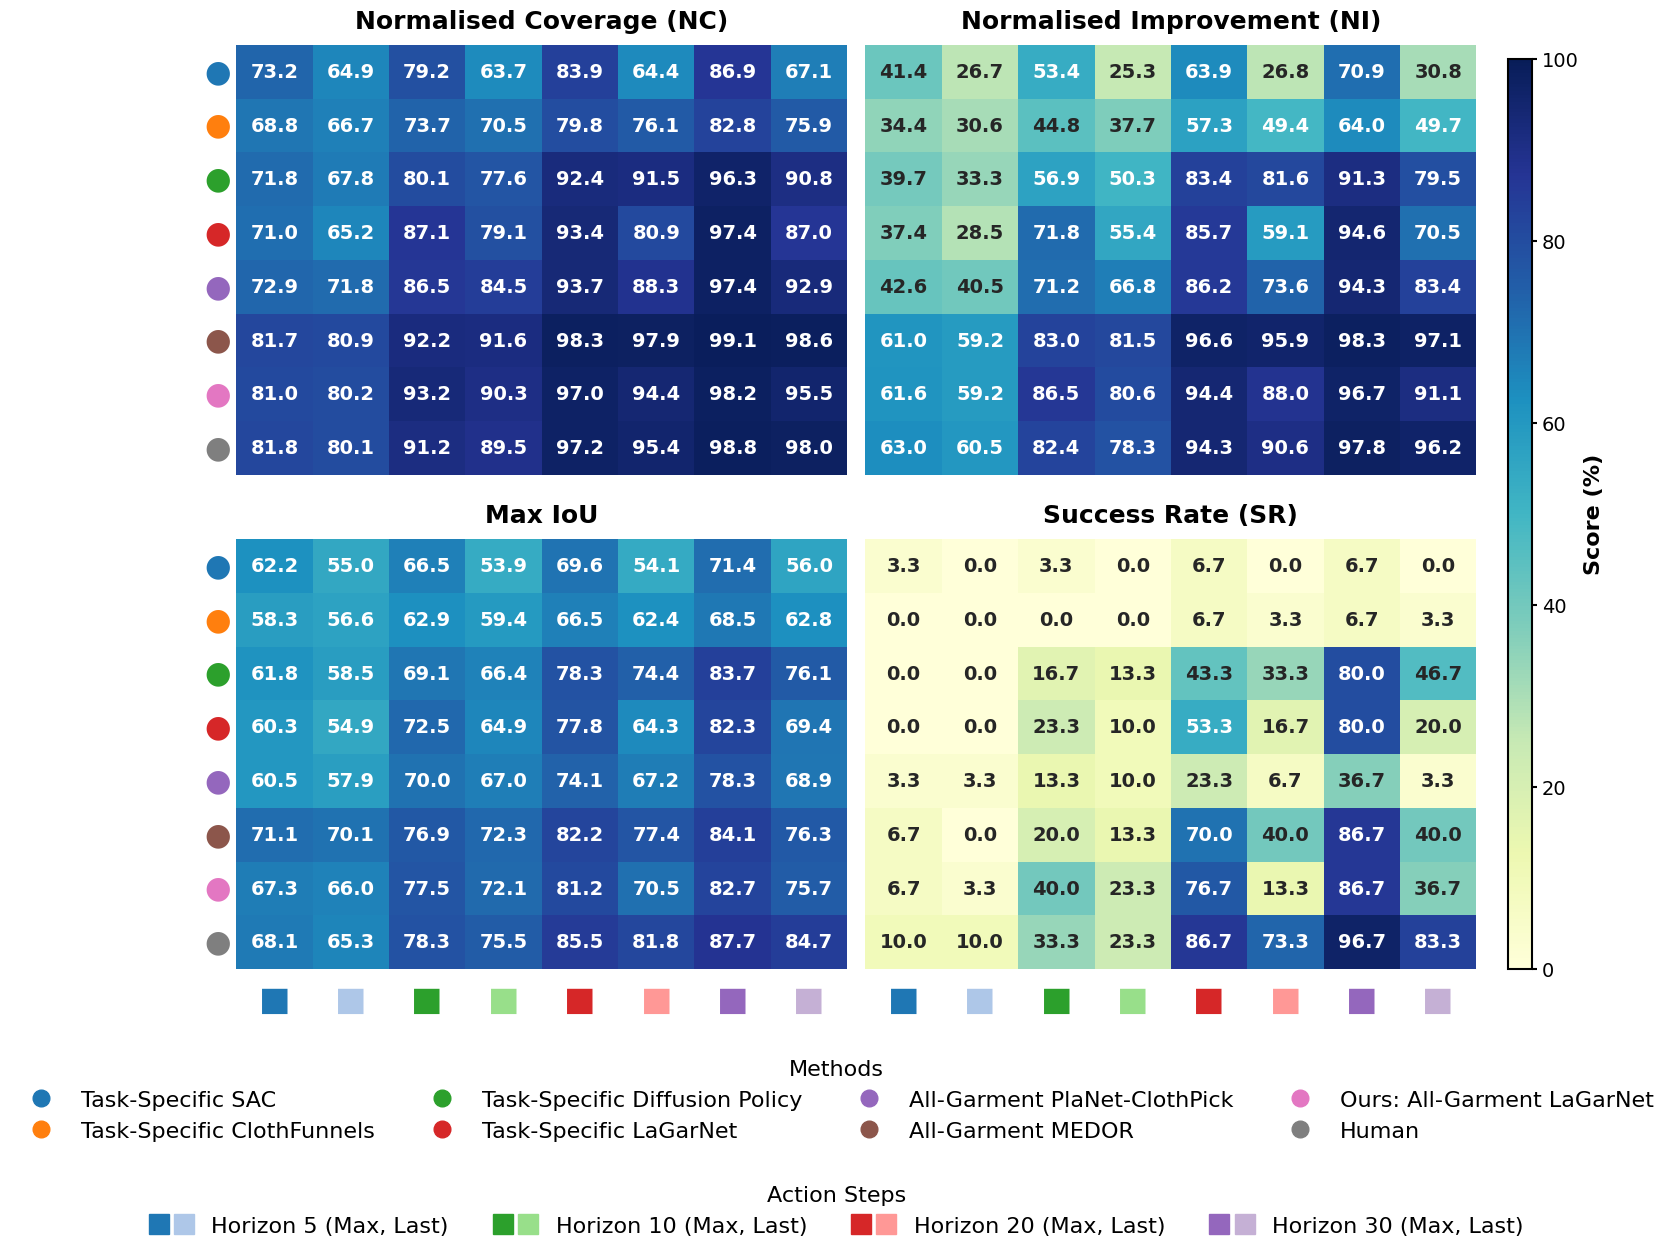

In [51]:
# --- Heatmap companion for the large Longsleeve transfer table (Max & Last per horizon) ---
# Mirrors analysis/magpie/alignment_sim.ipynb: one heatmap per metric (NC, NI, IoU, SR),
# rows = methods, columns = {Max, Last} x step horizons. The LaTeX table above is kept as-is;
# this is a visual companion. Reuses `data_dir`, `transfer_eval_exp`, `arenas`, `step_limits`
# defined in the LaTeX-table cell above.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerTuple

def plot_lagarnet_metrics_heatmap(data_dir, methods, arenas, step_limits=[5, 10, 20, 30],
                                  iou_thresh=0.8, nc_thresh=0.9,
                                  save_filename='lagarnet_metrics_heatmap.png'):
    labels = [m['label'] for m in methods]
    num_methods = len(labels)
    num_cols = len(step_limits) * 2  # Max + Last per horizon

    # Initialize data arrays
    data = {k: np.full((num_methods, num_cols), np.nan) for k in ['NC', 'NI', 'IoU', 'SR']}

    # Process data
    for i, exp in enumerate(methods):
        if exp.get('exp_dir') is None:
            continue
        for j, step in enumerate(step_limits):
            c_max, c_last = j * 2, j * 2 + 1
            acc = {kk: [] for kk in ['NC_max', 'NC_last', 'NI_max', 'NI_last',
                                     'IoU_max', 'IoU_last', 'SR_max', 'SR_last']}
            for arena in arenas:
                csv_path = os.path.join(data_dir, exp['exp_dir'], arena['exp_dir'],
                                        'eval_checkpoint_-2', 'performance.csv')
                if os.path.exists(csv_path):
                    m = aggregate_performance_custom(csv_path, iou_thresh=iou_thresh,
                                                     nc_thresh=nc_thresh, max_steps=step)
                    acc['NC_max'].append(m['Max NC_mean']);   acc['NC_last'].append(m['Final NC_mean'])
                    acc['NI_max'].append(m['Max NI_mean']);   acc['NI_last'].append(m['Final NI_mean'])
                    acc['IoU_max'].append(m['Max IoU_mean']); acc['IoU_last'].append(m['Final IoU_mean'])
                    acc['SR_max'].append(m['SR_mean']);       acc['SR_last'].append(m['Final SR_mean'])
            if acc['NC_max']:
                data['NC'][i, c_max]  = np.mean(acc['NC_max']);  data['NC'][i, c_last]  = np.mean(acc['NC_last'])
                data['NI'][i, c_max]  = np.mean(acc['NI_max']);  data['NI'][i, c_last]  = np.mean(acc['NI_last'])
                data['IoU'][i, c_max] = np.mean(acc['IoU_max']); data['IoU'][i, c_last] = np.mean(acc['IoU_last'])
                data['SR'][i, c_max]  = np.mean(acc['SR_max']);  data['SR'][i, c_last]  = np.mean(acc['SR_last'])

    # Convert all metrics to 0-100 scale
    for key in data:
        data[key] = data[key] * 100

    # Define color palettes
    method_colors = sns.color_palette("tab10", num_methods)
    # Dark colors for "Max", lighter variants for "Last"
    horizon_colors_dark = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']
    horizon_colors_light = ['#aec7e8', '#98df8a', '#ff9896', '#c5b0d5']

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    plot_configs = [
        (axes[0, 0], data['NC'],  'Normalised Coverage (NC)'),
        (axes[0, 1], data['NI'],  'Normalised Improvement (NI)'),
        (axes[1, 0], data['IoU'], 'Max IoU'),
        (axes[1, 1], data['SR'],  'Success Rate (SR)'),
    ]

    for ax, arr, title in plot_configs:
        is_left = ax in (axes[0, 0], axes[1, 0])
        is_bottom = ax in (axes[1, 0], axes[1, 1])
        
        # Replace text with unicode dots and squares
        y_labels = ['●'] * num_methods if is_left else False
        x_labels = ['■'] * num_cols if is_bottom else False

        # Updated vmax to 100 and fmt to '.1f'
        sns.heatmap(arr, annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=100, square=False,
                    mask=np.isnan(arr),
                    xticklabels=x_labels,
                    yticklabels=y_labels,
                    ax=ax, cbar=False, annot_kws={'size': 14, 'weight': 'bold'})
        
        ax.set_title(title, pad=12, fontsize=18, fontweight='bold')
        
        # Colorize the y-axis dots
        if is_left:
            ax.tick_params(axis='y', rotation=0, length=0)
            for i, tick in enumerate(ax.get_yticklabels()):
                tick.set_color(method_colors[i])
                tick.set_fontsize(22)
                
        # Colorize the x-axis squares
        if is_bottom:
            ax.tick_params(axis='x', rotation=0, length=0, pad=10)
            for j, tick in enumerate(ax.get_xticklabels()):
                horizon_idx = j // 2
                is_max = (j % 2 == 0)
                tick.set_color(horizon_colors_dark[horizon_idx] if is_max else horizon_colors_light[horizon_idx])
                tick.set_fontsize(24)
            ax.set_xlabel('') # Clear the text x-label

    # --- Setup Custom Legends ---
    
    # 1. Method Legend (Dots)
    method_handles = [mlines.Line2D([], [], color=method_colors[i], marker='o', linestyle='None',
                                    markersize=12, label=labels[i]) for i in range(num_methods)]
    
    # 2. Step Legend (Squares grouped as Max/Last tuples)
    step_handles = []
    step_labels_str = []
    for i, step in enumerate(step_limits):
        h_dark = mlines.Line2D([], [], color=horizon_colors_dark[i], marker='s', linestyle='None', markersize=14)
        h_light = mlines.Line2D([], [], color=horizon_colors_light[i], marker='s', linestyle='None', markersize=14)
        step_handles.append((h_dark, h_light))
        step_labels_str.append(f'Horizon {step} (Max, Last)')

    # Add legends to the figure bottom
    fig.legend(handles=method_handles, loc='upper center', bbox_to_anchor=(0.5, 0.17), 
               ncol=4, fontsize=16, title='Methods', title_fontsize=16, frameon=False)
    
    fig.legend(handles=step_handles, labels=step_labels_str, loc='upper center', bbox_to_anchor=(0.5, 0.08), 
               ncol=4, fontsize=16, title='Action Steps', title_fontsize=16, frameon=False, 
               handler_map={tuple: HandlerTuple(ndivide=None, pad=0.3)})

    # Set up global colorbar aligned with the tighter heatmaps
    cbar_ax = fig.add_axes([0.92, 0.22, 0.015, 0.65])
    # Updated colorbar normalization to 100 and label to percentage
    sm = plt.cm.ScalarMappable(cmap='YlGnBu', norm=plt.Normalize(vmin=0, vmax=100))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Score (%)', fontsize=16, fontweight='bold')
    cbar.ax.tick_params(labelsize=14)

    # Reduce heatmap gaps and leave vertical space at the bottom for the legends
    plt.subplots_adjust(wspace=0.03, hspace=0.15, right=0.9, bottom=0.22)
    plt.savefig(save_filename, bbox_inches='tight', dpi=300)
    print(f'Saved {save_filename}')
    plt.show()

# Methods / arena / horizons matching Table III (longsleeve flattening baseline comparison).
# NOTE: MEDOR data lives at transfer_eval_medor and SAC at transfer_eval_vanilla_image_sac;
# this list mirrors the paper's Table III columns exactly (verified to reproduce its numbers).
heatmap_data_dir = '/media/halid/T7/garment_folding_data/lagarnet_data'
heatmap_methods = [
    {'label': 'Task-Specific SAC',              'exp_dir': 'transfer_eval_vanilla_image_sac'},
    {'label': 'Task-Specific ClothFunnels',     'exp_dir': 'transfer_eval_cloth_funnels_place_only'},
    {'label': 'Task-Specific Diffusion Policy', 'exp_dir': 'transfer_eval_diffusion_200'},
    {'label': 'Task-Specific LaGarNet',         'exp_dir': 'transfer_eval_task_specific_lagarnet'},
    {'label': 'All-Garment PlaNet-ClothPick',   'exp_dir': 'transfer_eval_all_garment_planet_clothpick'},
    {'label': 'All-Garment MEDOR',              'exp_dir': 'transfer_eval_medor'},
    {'label': 'Ours: All-Garment LaGarNet',     'exp_dir': 'transfer_eval_final_lagarnet_reward_v2_alpha_0_3'},
    {'label': 'Human',                          'exp_dir': 'transfer_eval_human'},
]
heatmap_arenas = [{'exp_dir': 'multi_longsleeve_single_picker_readjust_pick_provide_semkey_pixel_no_success_stop_resol_128_train_200_horizon_30'}]
plot_lagarnet_metrics_heatmap(heatmap_data_dir, heatmap_methods, heatmap_arenas,
                              step_limits=[5, 10, 20, 30],
                              save_filename='lagarnet_flattening_heatmap.png')


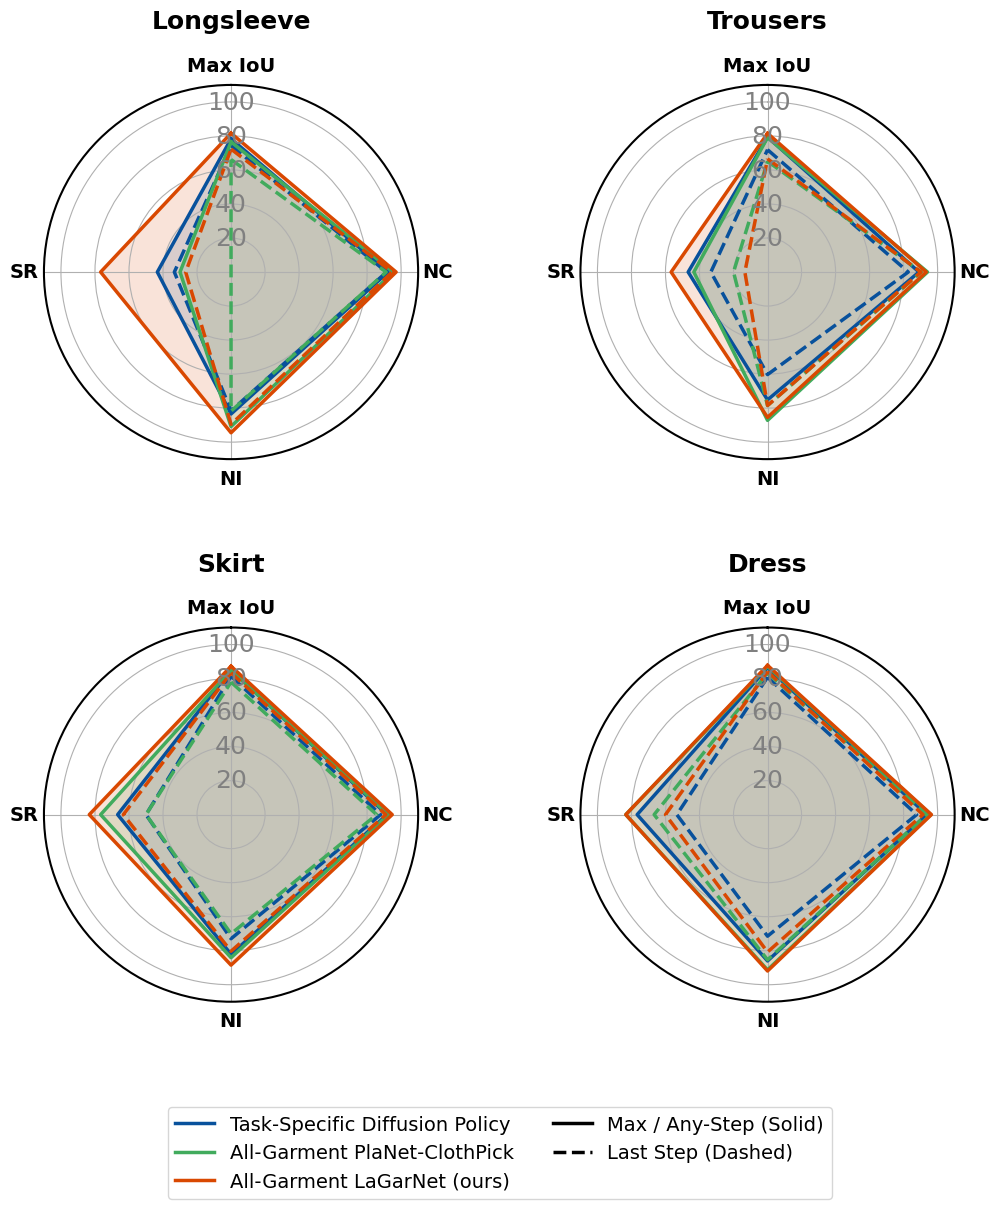

In [55]:
# Add these to your existing COLORS dictionary
COLORS.update({
    "All-Garment LaGarNet (ours)": '#d94801',            # Dark Orange
    "All-Garment PlaNet-ClothPick": '#41ab5d',     # Medium Green
    "Task-Specific Diffusion Policy": '#08519c'
})

def plot_multi_arena_radar(data_dir):
    """
    Creates a 2x2 grid of Radar Charts for Longsleeve, Trousers, Skirt, and Dress.
    The 2x2 (rather than 1x4) layout gives a near-square figure so the chart can sit
    side-by-side with the flattening heatmap in a single two-column LaTeX figure*.
    Compares Task-Specific Diffusion, All-Garment LaGarNet, and All-Garment PlaNet.
    Values are scaled to 0-100.
    """
    # --- 1. Define the Data Mappings ---
    arenas = [
        {'label': 'Longsleeve', 'exp_dir': 'multi_longsleeve_single_picker_readjust_pick_provide_semkey_pixel_no_success_stop_resol_128_train_200'},
        {'label': 'Trousers', 'exp_dir': 'multi_trousers_single_picker_readjust_pick_provide_semkey_pixel_no_success_stop_resol_128_train_200'},
        {'label': 'Skirt', 'exp_dir': 'multi_skirt_single_picker_readjust_pick_provide_semkey_pixel_no_success_stop_resol_128_train_200'},
        {'label': 'Dress', 'exp_dir': 'multi_dress_single_picker_readjust_pick_provide_semkey_pixel_no_success_stop_resol_128_train_200'}
    ]

    # Map methods to their base directories or specific arena dictionaries
    methods = {
        "Task-Specific Diffusion Policy": {
            "type": "specific",
            "paths": {
                "Longsleeve": "transfer_eval_diffusion_200/multi_longsleeve_single_picker_readjust_pick_provide_semkey_pixel_no_success_stop_resol_128_train_200_horizon_30",
                "Trousers": "diffusion_single_picker_single_primitive_multi_trousers_flattening_demo_200",
                "Skirt": "diffusion_single_picker_single_primitive_multi_skirt_flattening_demo_200",
                "Dress": "diffusion_single_picker_single_primitive_multi_dress_flattening_demo_200"
            }
        },
       
        "All-Garment PlaNet-ClothPick": {
            "type": "transfer",
            "base_dir": "transfer_eval_all_garment_planet_clothpick"
        },
        
        "All-Garment LaGarNet (ours)": {
            "type": "transfer",
            "base_dir": "transfer_eval_final_lagarnet_reward_v2_alpha_0_3"
        },
    }

    metrics_keys = ["Max IoU_mean", "Max NC_mean", "Max NI_mean", "SR_mean"]
    final_keys = ["Final IoU_mean", "Final NC_mean", "Final NI_mean", "Final SR_mean"]
    display_labels = ["Max IoU", "NC", "NI", "SR"]
    N = len(metrics_keys)
    
    # Calculate angles for radar plot
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1] # Close the loop
    
    # --- 2. Setup the Subplots ---
    fig, axes = plt.subplots(2, 2, figsize=(11, 11.5), subplot_kw=dict(polar=True))
    axes = axes.flatten()

    for i, arena in enumerate(arenas):
        ax = axes[i]
        arena_label = arena['label']
        
        # Format the axes
        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        
        plt.sca(ax)
        plt.xticks(angles[:-1], display_labels, fontweight='bold', fontsize=14)
        
        # Set 0-100 scale
        tick_vals = [20, 40, 60, 80, 100]
        tick_labels = ["20", "40", "60", "80", "100"]
        plt.yticks(tick_vals, [], color="grey")
        plt.ylim(0, 110)
        
        # Add a title to each subplot
        ax.set_title(arena_label, size=18, fontweight='bold', pad=20)
        
        # Draw the y-tick labels on the first axis only to avoid clutter
        for val, label in zip(tick_vals, tick_labels):
            ax.text(angles[0], val, label, color="grey", ha='center', va='center')

        # --- 3. Plot Data for Each Method ---
        for method_name, method_info in methods.items():
            # Construct the correct file path depending on the experiment type
            if method_info["type"] == "specific":
                exp_folder = method_info["paths"][arena_label]
                csv_path = os.path.join(data_dir, exp_folder, 'eval_checkpoint_-2', 'performance.csv')
            else:
                base_dir = method_info["base_dir"]
                csv_path = os.path.join(data_dir, base_dir, arena['exp_dir'], 'eval_checkpoint_-2', 'performance.csv')
                
            color = COLORS.get(method_name, 'gray')
            
            if os.path.exists(csv_path):
                # Calculate metrics
                metrics = aggregate_performance_custom(csv_path, iou_thresh=0.8, nc_thresh=0.9)
                
                # Extract and scale values to 0-100
                values = [metrics[k] * 100 for k in metrics_keys]
                values += values[:1] # Close the loop
                
                # Last-executed-step values (dashed, stability)
                final_values = [metrics[k] * 100 for k in final_keys]
                final_values += final_values[:1]
                # Plot: solid = Max / any-step, dashed = last step
                ax.plot(angles, values, linewidth=2.5, linestyle='solid', label=method_name, color=color)
                ax.fill(angles, values, color=color, alpha=0.15)
                ax.plot(angles, final_values, linewidth=2.5, linestyle='dashed', color=color)
            else:
                # Silently skip missing data (or print a warning if you want to debug)
                pass

    # --- 4. Custom Shared Legend ---
    # We create a single legend at the bottom center instead of repeating it 4 times
    custom_lines = [Line2D([0], [0], color=COLORS.get(method, 'gray'), lw=2.5) for method in methods.keys()]
    custom_labels = list(methods.keys())
    custom_lines.append(Line2D([0], [0], color='black', lw=2.5, linestyle='solid'))
    custom_labels.append('Max / Any-Step (Solid)')
    custom_lines.append(Line2D([0], [0], color='black', lw=2.5, linestyle='dashed'))
    custom_labels.append('Last Step (Dashed)')
    fig.legend(custom_lines, custom_labels, loc='lower center', ncol=2, frameon=True,
               fontsize=14, bbox_to_anchor=(0.5, -0.06))

    plt.tight_layout()
    # Adjust bottom margin so the layout doesn't clip the custom legend
    plt.subplots_adjust(bottom=0.12, hspace=0.45)
    
    plt.savefig('multi_arena_radar_2x2.png', dpi=300, bbox_inches='tight')
    plt.show()

# Run the function
plot_multi_arena_radar(data_dir='/media/halid/T7/garment_folding_data/lagarnet_data')

In [53]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Parsing and Aggregation Functions ---

def parse_list(x):
    """Safely parses string representations of lists from CSVs."""
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except ValueError:
            return []
    return x

def aggregate_performance_custom(csv_path, iou_thresh=0.8, nc_thresh=0.9, max_steps=20):
    """Calculates SR, Max IoU, Max NC, and Max NI for a single CSV."""
    df = pd.read_csv(csv_path)
    
    df["iou_flat"] = df["evaluation/max_IoU_to_flattened"].apply(parse_list)
    df["nc"] = df["evaluation/normalised_coverage"].apply(parse_list)
    df["ni"] = df["evaluation/normalised_improvement"].apply(parse_list)
    
    new_first_success_flags = []
    for iou_list, nc_list in zip(df["iou_flat"], df["nc"]):
        iou_sliced = iou_list[:max_steps] if max_steps is not None else iou_list
        nc_sliced = nc_list[:max_steps] if max_steps is not None else nc_list
        
        if any((i > iou_thresh and n > nc_thresh) for i, n in zip(iou_sliced, nc_sliced)):
            new_first_success_flags.append(1)
        else:
            new_first_success_flags.append(0)

    def safe_max(lst):
        sliced = lst[:max_steps] if max_steps is not None else lst
        return np.max(sliced) if len(sliced) > 0 else 0.0

    def safe_final(lst):
        """Value at the last executed step within the horizon (stability)."""
        sliced = lst[:max_steps] if max_steps is not None else lst
        return sliced[-1] if len(sliced) > 0 else 0.0

    max_iou = [safe_max(x) for x in df["iou_flat"]]
    max_nc = [safe_max(x) for x in df["nc"]]
    max_ni = [safe_max(x) for x in df["ni"]]

    final_iou = [safe_final(x) for x in df["iou_flat"]]
    final_nc = [safe_final(x) for x in df["nc"]]
    final_ni = [safe_final(x) for x in df["ni"]]
    final_success_flags = [
        1 if (fi > iou_thresh and fn > nc_thresh) else 0
        for fi, fn in zip(final_iou, final_nc)
    ]

    return {
        "SR_mean": np.mean(new_first_success_flags),
        "Max IoU_mean": np.mean(max_iou),
        "Max NC_mean": np.mean(max_nc),
        "Max NI_mean": np.mean(max_ni),
        "Max IoU_std": np.std(max_iou),
        "Max NC_std": np.std(max_nc),
        "Max NI_std": np.std(max_ni),
        "Final SR_mean": np.mean(final_success_flags),
        "Final IoU_mean": np.mean(final_iou),
        "Final NC_mean": np.mean(final_nc),
        "Final NI_mean": np.mean(final_ni),
        "Final IoU_std": np.std(final_iou),
        "Final NC_std": np.std(final_nc),
        "Final NI_std": np.std(final_ni),
    }

def get_all_garment_metrics(data_dir, method_base_dir):
    """Averages the performance of a method across all 4 garment arenas and calculates std."""
    arenas = [
        'multi_longsleeve_single_picker_readjust_pick_provide_semkey_pixel_no_success_stop_resol_128_train_200',
        'multi_trousers_single_picker_readjust_pick_provide_semkey_pixel_no_success_stop_resol_128_train_200',
        'multi_skirt_single_picker_readjust_pick_provide_semkey_pixel_no_success_stop_resol_128_train_200',
        'multi_dress_single_picker_readjust_pick_provide_semkey_pixel_no_success_stop_resol_128_train_200'
    ]
    
    all_metrics = []
    for arena in arenas:
        csv_path = os.path.join(data_dir, method_base_dir, arena, 'eval_checkpoint_-2', 'performance.csv')
        if os.path.exists(csv_path):
            metrics = aggregate_performance_custom(csv_path)
            all_metrics.append(metrics)
        else:
            print(f"Warning: Missing data at {csv_path}")

    if not all_metrics:
        return None

    # Macro-average and standard deviation across the successfully loaded garments
    avg_metrics = {}
    for key in all_metrics[0].keys():
        values = [m[key] for m in all_metrics]
        avg_metrics[key] = np.mean(values)
        avg_metrics[f"{key}_std"] = np.std(values) # Added standard deviation
    
    return avg_metrics

# --- 2. Plotting Functions ---

def plot_grouped_bar_chart(data_dir, methods_dict, save_filename):
    """Plots a grouped bar chart with inside labels, no title, and std error bars (except for SR)."""
    metrics_keys = ["Max IoU_mean", "Max NC_mean", "Max NI_mean", "SR_mean"]
    display_labels = ["Max IoU", "NC", "NI", "SR"]
    
    # Gather data
    method_names = list(methods_dict.keys())
    data_matrix = np.zeros((len(metrics_keys), len(method_names)))
    std_matrix = np.zeros((len(metrics_keys), len(method_names))) # Matrix for std dev
    
    for j, (name, base_dir) in enumerate(methods_dict.items()):
        metrics = get_all_garment_metrics(data_dir, base_dir)
        if metrics:
            for i, key in enumerate(metrics_keys):
                data_matrix[i, j] = metrics[key] * 100 # Scale mean to 0-100
                
                # Check if the metric is SR. If so, set std to 0 so it won't draw an error bar.
                if key == "SR_mean":
                    std_matrix[i, j] = 0.0
                else:
                    std_matrix[i, j] = metrics[f"{key}_std"] * 100 # Scale std to 0-100
                
    # Plotting - Increased figsize to handle huge fonts
    x = np.arange(len(display_labels))
    width = 0.8 / len(method_names) 
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    for j, name in enumerate(method_names):
        offset = (j - len(method_names)/2) * width + width/2
        
        # Added yerr and capsize for standard deviation bars
        ax.bar(x + offset, data_matrix[:, j], width, label=name, 
               yerr=std_matrix[:, j], capsize=5, 
               edgecolor='black', alpha=0.8,
               error_kw=dict(lw=1.5, capthick=1.5, alpha=0.7)) # Error bar styling

    ax.set_xticks(x)
    # Doubled xtick label size
    ax.set_xticklabels(display_labels, fontsize=24)
    
    # Doubled ytick label size
    ax.tick_params(axis='y', labelsize=20)
    
    ax.set_ylim(0, 115) 
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # --- Inside Labels & Legend ---
    text_bbox = dict(facecolor='white', alpha=0.8, edgecolor='none', pad=4)
    
    # Y-label: Top-Left Inside - Doubled fontsize
    ax.text(0.01, 0.97, 'Performance (%)', transform=ax.transAxes, 
            fontsize=16, va='top', ha='left', bbox=text_bbox)
    
    # Legend: Placed inside - Doubled fontsize
    ax.legend(loc='lower left', fontsize=16, framealpha=0.9, ncols=2)
    
    plt.tight_layout()
    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    print(f"Saved {save_filename}")
    plt.close()
    
def plot_data_size_line_chart(data_dir, methods_dict, save_filename):
    """Plots a line chart with scientific inside labels and no title."""
    metrics_keys = ["Max IoU_mean", "Max NC_mean", "Max NI_mean", "SR_mean"]
    display_labels = ["Max IoU", "NC", "NI", "SR"]
    markers = ['o', 's', '^', 'D']
    
    # Extract numerical eps sizes and data
    sizes = []
    data_matrix = {key: [] for key in metrics_keys}
    
    for size_str, base_dir in methods_dict.items():
        metrics = get_all_garment_metrics(data_dir, base_dir)
        if metrics:
            sizes.append(int(size_str.replace(' eps', '')))
            for key in metrics_keys:
                data_matrix[key].append(metrics[key] * 100)

    # Increased figsize to handle huge fonts
    fig, ax = plt.subplots(figsize=(8, 6))
    
    for (key, label, marker) in zip(metrics_keys, display_labels, markers):
        sorted_indices = np.argsort(sizes)
        sorted_sizes = np.array(sizes)[sorted_indices]
        sorted_data = np.array(data_matrix[key])[sorted_indices]
        
        ax.plot(sorted_sizes, sorted_data, marker=marker, linewidth=4.0, markersize=12, label=label) # Thickened lines/markers to match giant text

    ax.set_xscale('log') 
    ax.set_ylim(0, 115)
    
    # Doubled ytick label size
    ax.tick_params(axis='y', labelsize=16)
    
    # --- Custom Scientific Tick Formatter ---
    def format_scientific(x):
        coeff, exp = f"{x:.0e}".split('e')
        exp = int(exp) # Removes leading zeros and plus/minus signs
        if coeff == '1':
            return f"$10^{{{exp}}}$"
        return f"${coeff} \\times 10^{{{exp}}}$"

    ax.set_xticks(sorted_sizes)
    # Apply scientific formatting to the labels - Doubled fontsize
    ax.set_xticklabels([format_scientific(s) for s in sorted_sizes], fontsize=16)
    
    ax.grid(True, which="both", linestyle='--', alpha=0.7)
    
    # --- Inside Labels & Legend ---
    text_bbox = dict(facecolor='white', alpha=0.8, edgecolor='none', pad=4)
    
    # Y-label: Top-Left Inside - Doubled fontsize
    ax.text(0.01, 0.97, 'Performance (%)', transform=ax.transAxes, 
            fontsize=16, fontweight='bold', va='top', ha='left', bbox=text_bbox)
            
    # X-label: Bottom-Left Inside - Doubled fontsize
    ax.text(0.01, 0.03, 'Episodes (Log Scale)', transform=ax.transAxes, 
            fontsize=16, fontweight='bold', va='bottom', ha='left', bbox=text_bbox)
    
    # Legend: Lower right - Doubled fontsize
    ax.legend(loc='lower right', fontsize=16, framealpha=0.9)
    
    plt.tight_layout()
    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    print(f"Saved {save_filename}")
    plt.close()


# --- 3. Execution Block ---

def generate_all_plots(data_dir):
    
    # 1. Reward Ablations (Grouped Bar Chart)
    reward_methods = {
        'L2U': 'transfer_eval_final_lagarnet_l2u_reward',
        'CF': 'transfer_eval_final_lagarnet_cf_reward',
        'PC': 'transfer_eval_final_lagarnet_pc_reward',
        'SFA': 'transfer_eval_final_lagarnet_sfa_reward',
        'Ours (CA)': 'transfer_eval_final_lagarnet_reward_v2_alpha_0_3'
    }
    plot_grouped_bar_chart(data_dir, reward_methods, 'ablation_reward_bar.png')

    # 2. Latent Structure Ablations (Grouped Bar Chart)
    latent_methods = {
        'GC-RSSM (ours)': 'transfer_eval_gc_rssm',
        'RSSM': 'transfer_eval_rssm',
        'RSSM-GC-I': 'transfer_eval_rssm_gc_i',
        'RSSM-GC-IO': 'transfer_eval_rssm_gc_io'
    }
    plot_grouped_bar_chart(data_dir, latent_methods, 'ablation_latent_bar.png')

    # 3. Data Size Ablations (Line Chart)
    data_methods = {
        '100 eps': 'transfer_eval_final_lagarnet_100_eps',
        '500 eps': 'transfer_eval_final_lagarnet_500_eps',
        '1000 eps': 'transfer_eval_final_lagarnet_1000_eps',
        '5000 eps': 'transfer_eval_lagarnet_reward_v2',
        '10000 eps': 'transfer_eval_final_lagarnet_10000_eps',
        '40000 eps': 'transfer_eval_final_lagarnet_40000_eps'
    }
    plot_data_size_line_chart(data_dir, data_methods, 'ablation_data_size_line.png')

if __name__ == '__main__':
    DATA_DIR = '/media/halid/T7/garment_folding_data/lagarnet_data'
    generate_all_plots(DATA_DIR)

Saved ablation_reward_bar.png
Saved ablation_latent_bar.png
Saved ablation_data_size_line.png


--- MPC Planning Ablation (values x100; runtime in seconds) ---
            Variant   H  Trajectories    SR  Final SR  Max IoU  Max IoU Std  Max NC  Max NC Std  Max NI  Max NI Std  Final IoU  Final IoU Std  Final NC  Final NC Std  Final NI  Final NI Std  Plan Time (s)  Plan Time Std
                H=1 1.0            30 50.00     26.67    79.62         4.34   98.50        4.15   96.35       11.55      69.95           9.30     94.20          9.59     87.38         22.26           4.10           0.04
                H=2 2.0            30 40.00      3.33    77.87         4.71   98.03        4.88   95.35       12.03      69.31           6.24     91.46          8.16     80.97         16.63           4.46           0.29
                H=3 3.0            30 26.67      0.00    77.22         4.45   97.58        4.59   94.50       10.23      66.93           6.38     91.42          7.15     79.04         18.82           4.67           0.21
                H=5 5.0            30 20.00      0.00   

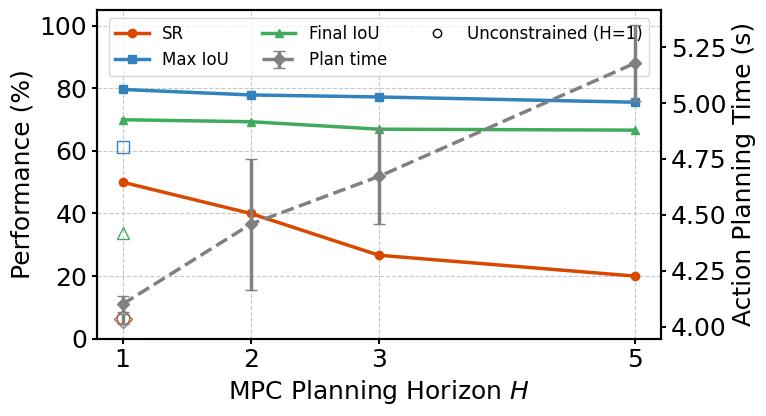

In [54]:
# --- MPC Planning Ablation: horizons (H = 1, 2, 3, 5) + unconstrained CEM at H=1 ---
import ast
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_dir = globals().get('data_dir', '/media/halid/T7/garment_folding_data')

HORIZON_EVAL_BASE = 'transfer_eval_final_lagarnet_horizon'
HORIZON_ARENA = 'multi_longsleeve_single_picker_readjust_pick_provide_semkey_pixel_no_success_stop_resol_128_train_200'
# (dir tag, display label, numeric horizon for the plot or None to exclude)
VARIANTS = [
    ('H1', 'H=1', 1),
    ('H2', 'H=2', 2),
    ('H3', 'H=3', 3),
    ('H5', 'H=5', 5),
    ('H1_unconstrained', 'H=1 (no constraint)', None),
]

def _parse_list(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return []
    return x

horizon_rows = []
for tag, label, H in VARIANTS:
    base = os.path.join(data_dir, f'{HORIZON_EVAL_BASE}_{tag}', HORIZON_ARENA, 'eval_checkpoint_-2')
    perf_csv = os.path.join(base, 'performance.csv')
    runtime_csv = os.path.join(base, 'runtime.csv')
    if not os.path.exists(perf_csv):
        print(f'Missing {perf_csv}; skipping {label}')
        continue

    m = aggregate_performance_custom(perf_csv, iou_thresh=0.8, nc_thresh=0.9)
    n_traj = len(pd.read_csv(perf_csv))
    row = {
        'Variant': label,
        'H': H if H is not None else np.nan,
        'Trajectories': n_traj,
        'SR': m['SR_mean'] * 100,
        'Final SR': m['Final SR_mean'] * 100,
        'Max IoU': m['Max IoU_mean'] * 100, 'Max IoU Std': m['Max IoU_std'] * 100,
        'Max NC': m['Max NC_mean'] * 100, 'Max NC Std': m['Max NC_std'] * 100,
        'Max NI': m['Max NI_mean'] * 100, 'Max NI Std': m['Max NI_std'] * 100,
        'Final IoU': m['Final IoU_mean'] * 100, 'Final IoU Std': m['Final IoU_std'] * 100,
        'Final NC': m['Final NC_mean'] * 100, 'Final NC Std': m['Final NC_std'] * 100,
        'Final NI': m['Final NI_mean'] * 100, 'Final NI Std': m['Final NI_std'] * 100,
    }

    if os.path.exists(runtime_csv):
        rt = pd.read_csv(runtime_csv)
        step_times = [t for lst in rt['planning_times_s'].apply(_parse_list) for t in lst]
        row['Plan Time (s)'] = np.mean(step_times)
        row['Plan Time Std'] = np.std(step_times)
    else:
        print(f'Missing {runtime_csv}; runtime omitted for {label}')
        row['Plan Time (s)'] = np.nan
        row['Plan Time Std'] = np.nan

    horizon_rows.append(row)

df_horizon = pd.DataFrame(horizon_rows)
if df_horizon.empty:
    print('No planning ablation data found yet.')
else:
    print('--- MPC Planning Ablation (values x100; runtime in seconds) ---')
    print(df_horizon.round(2).to_string(index=False))

    # LaTeX table
    df_tab = pd.DataFrame()
    df_tab['Variant'] = df_horizon['Variant']
    df_tab['SR'] = df_horizon['SR'].apply(lambda x: f'{x:.1f}')
    df_tab['Final SR'] = df_horizon['Final SR'].apply(lambda x: f'{x:.1f}')
    for name in ['Max IoU', 'Max NC', 'Max NI', 'Final IoU', 'Final NC', 'Final NI']:
        df_tab[name] = df_horizon.apply(lambda r: f"{r[name]:.1f} $\pm$ {r[name + ' Std']:.1f}", axis=1)
    df_tab['Plan Time (s)'] = df_horizon.apply(lambda r: f"{r['Plan Time (s)']:.2f} $\pm$ {r['Plan Time Std']:.2f}", axis=1)
    print('\n--- LaTeX Table Output ---')
    print(df_tab.to_latex(index=False, escape=False, column_format='l' + 'c' * (len(df_tab.columns) - 1)))

    # Dual-axis plot over the constrained horizon sweep only
    df_sweep = df_horizon[df_horizon['H'].notna()].sort_values('H')
    if not df_sweep.empty:
        fig, ax1 = plt.subplots(figsize=(8, 4.5))
        
        # Plot Constrained Sweep
        ax1.plot(df_sweep['H'], df_sweep['SR'], marker='o', label='SR', color='#d94801')
        ax1.plot(df_sweep['H'], df_sweep['Max IoU'], marker='s', label='Max IoU', color='#3182bd')
        ax1.plot(df_sweep['H'], df_sweep['Final IoU'], marker='^', label='Final IoU', color='#41ab5d')
        
        ax1.set_xlabel('MPC Planning Horizon $H$')
        ax1.set_ylabel('Performance (%)')
        ax1.set_xticks(list(df_sweep['H']))
        ax1.set_ylim(0, 105)
        ax1.grid(True, linestyle='--', alpha=0.7)

        # Plot Plan Time on second axis
        ax2 = ax1.twinx()
        ax2.errorbar(df_sweep['H'], df_sweep['Plan Time (s)'], yerr=df_sweep['Plan Time Std'],
                     marker='D', color='gray', linestyle='--', capsize=4, label='Plan time')
        ax2.set_ylabel('Action Planning Time (s)')

        # --- NEW: Plot Unconstrained H=1 ---
        df_unc = df_horizon[df_horizon['Variant'] == 'H=1 (no constraint)']
        if not df_unc.empty:
            unc_row = df_unc.iloc[0]
            # Plot at x=1 with empty filling (markerfacecolor='none') and matching edge colors/shapes
            ax1.plot(1, unc_row['SR'], marker='o', color='#d94801', markerfacecolor='none', markersize=9, linestyle='None')
            ax1.plot(1, unc_row['Max IoU'], marker='s', color='#3182bd', markerfacecolor='none', markersize=9, linestyle='None')
            ax1.plot(1, unc_row['Final IoU'], marker='^', color='#41ab5d', markerfacecolor='none', markersize=9, linestyle='None')
            
            ax2.errorbar(1, unc_row['Plan Time (s)'], yerr=unc_row['Plan Time Std'], 
                         marker='D', color='gray', markerfacecolor='none', capsize=4, markersize=9, linestyle='None')

        # Legend Handling
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        
        # Create a custom legend handle to explain what the empty markers mean
        import matplotlib.lines as mlines
        unc_legend = mlines.Line2D([], [], color='black', marker='o', markerfacecolor='none', 
                                   linestyle='None', label='Unconstrained (H=1)')
        
        # Combine all legend items, place at the bottom, outside the plot area
        ax1.legend(lines1 + lines2 + [unc_legend], labels1 + labels2 + ['Unconstrained (H=1)'], 
                   loc='upper center', fontsize=12, ncol=3)

        plt.tight_layout()
        plt.savefig('ablation_mpc_horizon.png', dpi=300, bbox_inches='tight')
        print('Saved ablation_mpc_horizon.png')
        plt.show()